# **Machine Learning**

## 학습목표
- 머신러닝에 대한 기본 개념을 이해한다.
- 데이터 예측 모델링의 프로세스를 이해하고 수행할 수 있다.
- 지도 학습과 비지도 학습의 차이점을 이해하고 활용한다.
- 머신러닝 대표적인 문제 유형과 그에 대한 알고리즘을 학습하고 적용할 수 있다.
- 데이터 분석 및 모델 평가를 수행하여 문제 해결에 활용할수 있는 능력을 갖춘다.

## 기대효과

- 머신러닝에 대한 기본적인 이해를 통해 다양한 분야에서 머신러닝을 적용할 수 있는 시야를 확장한다.
- 데이터 예측 모델링의 프로세스를 체계적으로 수행할 수 있는 능력을 갖춘다.
- 대표적인 문제 유형과 알고리즘을 학습하여 실제 상황에서 문제 해결에 적용할 수 있다.
- 데이터 분석과 모델 평가를 통해 효과적인 문제 해결 방법을 도출할 수 있다.
- 머신러닝 관련 업무에 대한 이해도와 역량을 향상시켜 진로나 업무에서의 성과를 향상시킬 수 있다.

# 실습 내용

- 머신러닝 모델링을 위한 코딩은 무조건 할 수 있어야 한다.
- 코딩 내용을 자세히 알지 못해도 일단 **무작정** 코딩을 진행해본다.
- AirQuality 데이터를 대상으로 모델링 해서 오존 농도를 예측해본다.
- LinearRegression 알고리즘 사용

- sklearn 버전 확인 및 필요시 업그레이드

In [77]:
# 모듈 설치
# %pip install scikit-learn

In [78]:
# sklearn 버전 확인
import sklearn
print(sklearn.__version__)

1.8.0


In [79]:
# sklearn 버전 업그레이드
# %pip install scikit-learn --user --upgrade

- 업그레이를 하게 되면 Kernel 재시작 후 버전 다시 확인

# 1.환경 준비

- 기본 **라이브러리**와 대상 **데이터**를 가져와 이후 과정을 준비한다.

In [80]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [81]:
path = 'data/airquality.csv'
df = pd.read_csv(path)

df

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


# 2.데이터 이해

- 해결해야 할 **문제를 명확히 정의**하고, 모델링을 통해서 얻고자 하는 **내용 및 구체적 결과물**을 정의한다.
- 분석할 데이터를 **충분히 이해**할 수 있도록 다양한 **탐색** 과정을 수행한다.
- 현재 가지고 있는 데이터의 수준으로 문제를 해결할 수 있는지 점검한다.

In [82]:
# 상위 5개 행 확인
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [83]:
# 하위 5개 행 확인
df.tail()

,Ozone,Solar.R,Wind,Temp,Month,Day
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29
152,20.0,223.0,11.5,68,9,30


In [84]:
# 변수 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


In [85]:
# 기술통계 확인
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [86]:
# 상관 관계 확인
df.corr()

,Ozone,Solar.R,Wind,Temp,Month,Day
Ozone,1.000000,0.348342,-0.601547,0.698360,0.164519,-0.013226
Solar.R,0.348342,1.000000,-0.056792,0.275840,-0.075301,-0.150275
Wind,-0.601547,-0.056792,1.000000,-0.457988,-0.178293,0.027181
Temp,0.698360,0.275840,-0.457988,1.000000,0.420947,-0.130593
Month,0.164519,-0.075301,-0.178293,0.420947,1.000000,-0.007962
Day,-0.013226,-0.150275,0.027181,-0.130593,-0.007962,1.000000


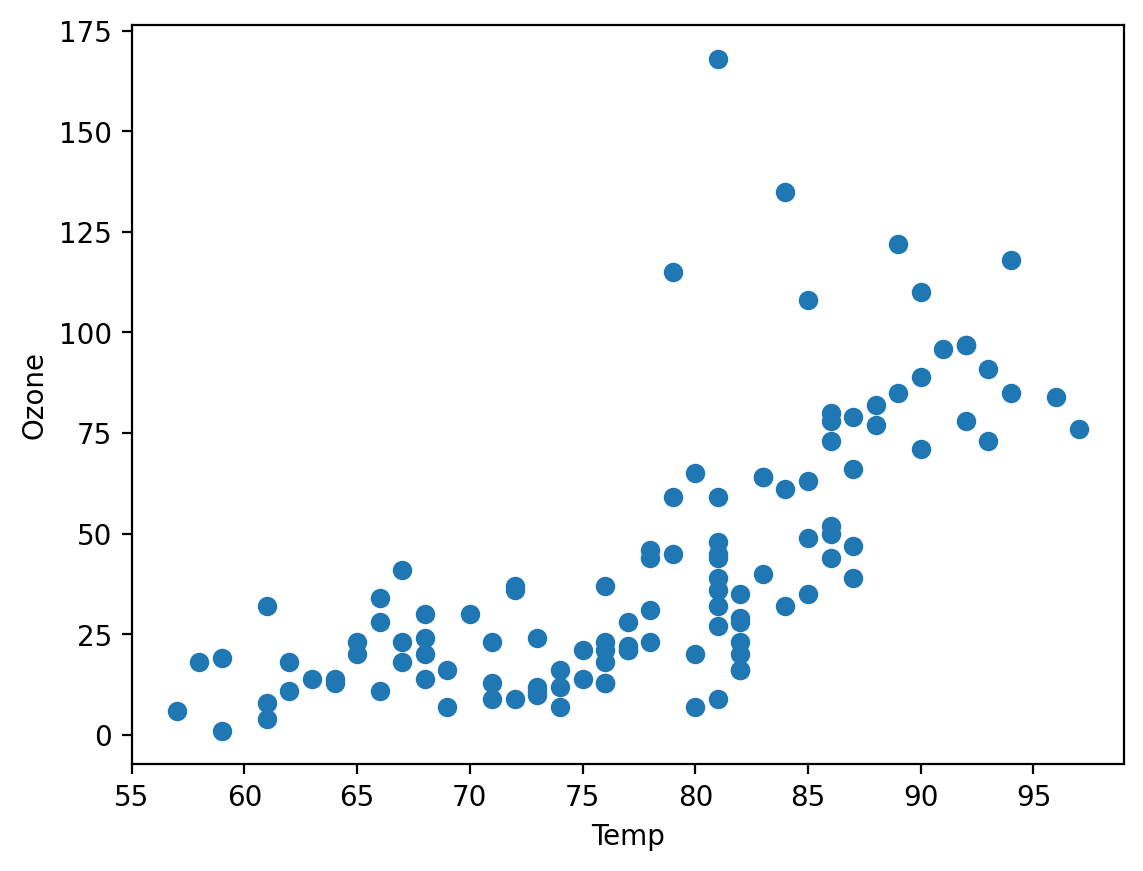

In [87]:
#상관 관계 시각화 : Temp -> Ozone
plt.scatter(df['Temp'], df['Ozone'])
plt.xlabel('Temp')
plt.ylabel('Ozone')
plt.show()

<Axes: >

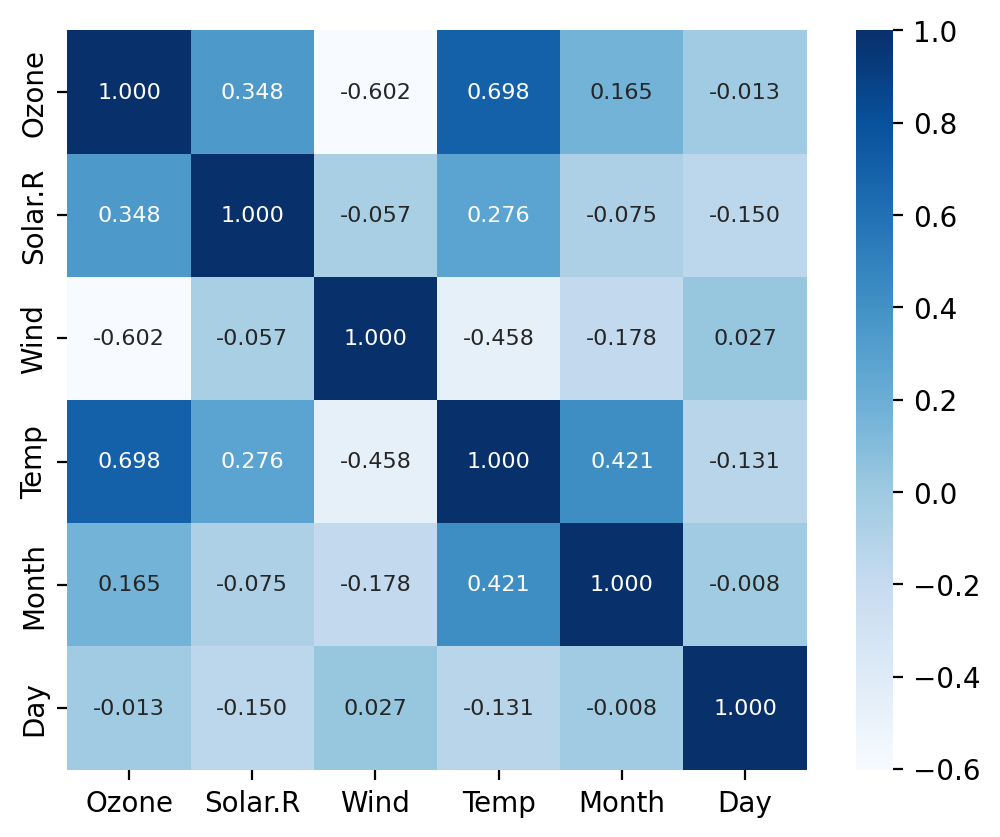

In [88]:
# 전체 변수 상관 관계 시각화
sns.heatmap(df.corr(),
            annot=True,
            cmap='Blues',
            cbar='False',
            square=True,
            fmt='.3f',
            annot_kws={'size':8}
            )

# 여기까지가 EDA

# 3.데이터 전처리

- 수집한 데이터를 모델링에 적합한 형태로 변환하는 단계이다.
- **전처리** 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비한다.
- 누락된 값(NA)이나 이상치를 처리하고, 범주형 변수를 인코딩한다.
- 데이터를 정규화하거나 표준화하는 등의 스케일링 작업을 수행한다.
- 모델(알고리즘)에서 인식할 수 있는 형태의 데이터 set을 만드는 작업이다.

**1) 결측치 처리**

- 결측치가 있으면 제거하거나 적절한 값으로 채운다.

In [89]:
df.isna().sum()


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [90]:
# 전날 값으로 결측치 채우기
df = df.ffill()
df.isna().sum()

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**2) Feature Engineering**

- 모델의 성능 향상을 위해 Feature를 생성, 선택, 가공 등을 하는 일련의 모든 활동이다.
- 모델의 성능에 큰 영향을 미치는 중요한 단계로, 도메인 지식을 활용하여 데이터의 의미를 잘 표현하는 특성들을 생성하는 것이 핵심이다.
- 분석에 의미가 없다고 판단되는 변수는 제거한다.

In [91]:
# 변수 제거
drop_cols = ['Month', 'Day']
df.drop(drop_cols, axis=1, inplace=True)

df

,Ozone,Solar.R,Wind,Temp
0,41.0,190.0,7.4,67
1,36.0,118.0,8.0,72
2,12.0,149.0,12.6,74
3,18.0,313.0,11.5,62
4,18.0,313.0,14.3,56
...,...,...,...,...
148,30.0,193.0,6.9,70
149,30.0,145.0,13.2,77
150,14.0,191.0,14.3,75
151,18.0,131.0,8.0,76


**3) x, y 분리**

- 우선 target 변수를 명확히 지정한다.
- target을 제외한 나머지 변수들 데이터는 X로 선언한다.
- target 변수 데이터는 y로 선언한다.
- 이 결과로 만들어진 X는 데이터프레임, y는 시리즈가 된다.
- 이후 모든 작업은 X, y를 대상으로 진행한다.

In [92]:
# target 확인
target = 'Ozone'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]


**4) 학습용, 평가용 데이터 분리**

- 학습용, 평가용 데이터를 적절한 비율로 분리한다.
- 반복 실행 시 동일한 결과를 얻기 위해 random_state 옵션을 지정한다.

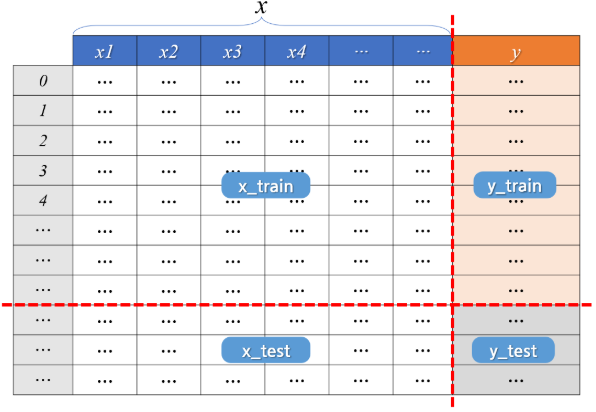

In [103]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3, # 30퍼센트, 8:2 일 때는 0.2
                                                    shuffle=True, # 섞은 후 나눈다. 한쪽으로 치우치는 경우는 배제하기 위해서
                                                    random_state=200)


In [94]:
X_train[:10] # head(10) 써도 상관없다.

,Solar.R,Wind,Temp
11,256.0,9.7,69
100,207.0,8.0,90
28,252.0,14.9,81
128,92.0,15.5,84
0,190.0,7.4,67
27,13.0,12.0,67
36,264.0,14.3,79
109,115.0,7.4,76
144,14.0,9.2,71
134,259.0,15.5,76


# 4.모델링

- 본격적으로 모델을 **선언**하고 **학습**하고 **평가**하는 과정을 진행한다.
- 우선 **회귀** 문제인지 **분류** 문제인지  문제 유형을 명확히 구분하여, 사용할 알고리즘에 대한 탐색을 통해 알고리즘 List-up을 해야 한다.

**1) 모델링**

- 회귀 문제 인가? 분류 문제인가?
- 회귀인지 분류인지에 따라 사용할 알고리즘과 평가 방법이 달라진다.
- 우선 다음 알고리즘과 평가 방법을 사용한다.
    - 알고리즘: LinearRegression
    - 평가방법: mean_absolute_error

In [95]:
# 1단계: 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [98]:
# 2단계: 선언하기
model = LinearRegression()

In [99]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
# 4단계: 예측하기
y_pred = model.predict(X_test)

In [111]:
# 실제값과 예측값 비교
print(y_test.values[:10])
print(y_pred[:10])

[20. 35. 13. 82. 71.  7. 32. 63. 20. 37.]
[ 11.3935859   52.67235039  51.0728503   65.28182581  57.71965033
  16.3808058  -18.62216408  50.6518944   44.80336079   9.53789288]


In [104]:
# 5단계: 평가하기
mean_absolute_error(y_test, y_pred)

34.80139763719311

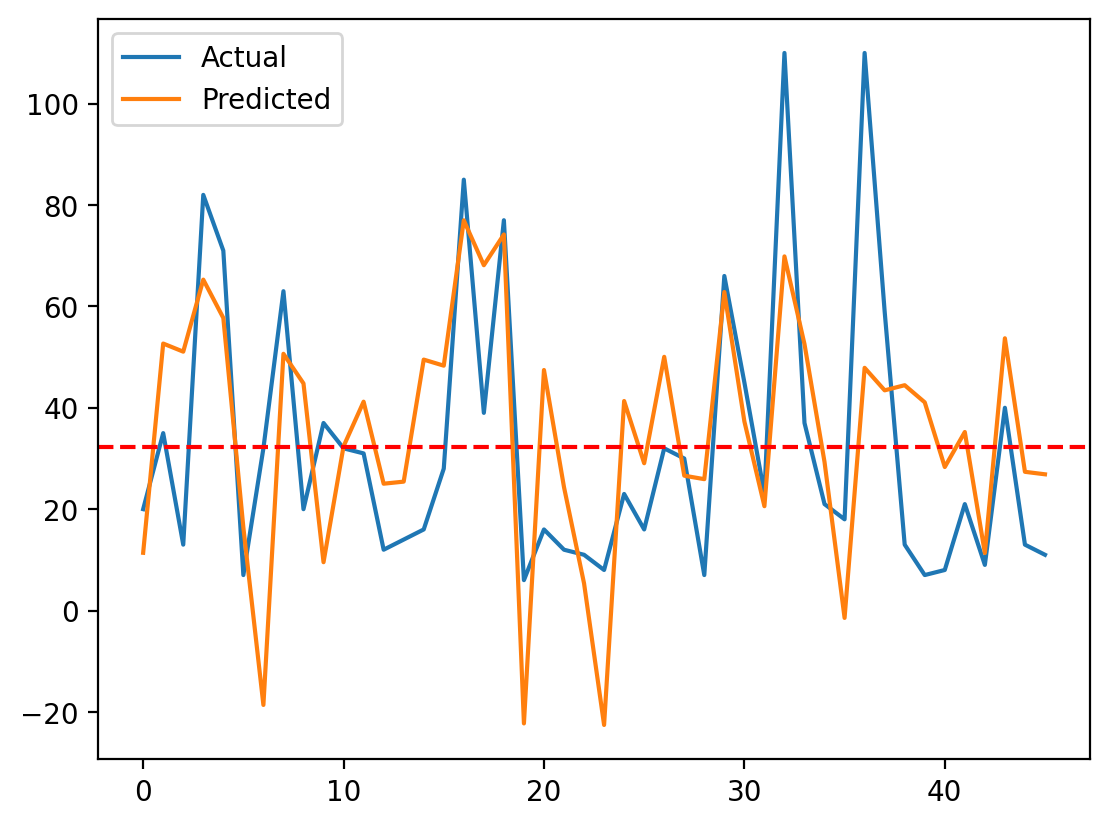

In [109]:
# 실제값과 예측값 시각화
mean_ozone = y_test.mean()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.axhline(mean_ozone, color='r', linestyle='--')
plt.legend()
plt.show()